# Phase 8 — Notebook 7: GPT-3, GPT-4 & The Era of Emergent Abilities

> **Phase Continuity**: Notebook 6 showed how GPT-1 and GPT-2 established the autoregressive Decoder paradigm. This notebook explores what happens when that architecture is scaled by **1,000×** — and the surprising emergent capabilities that appeared, culminating in ChatGPT and GPT-4.

---

## 1. GPT-3 — The Scale Breakthrough (2020)

GPT-3 (Brown et al., 2020) scaled GPT-2 by roughly 100× in parameters. The core architecture change was minimal — the same decoder-only Transformer — but the scale transformed what the model could do:

| | GPT-2 XL | GPT-3 |
|---|---|---|
| **Layers** | 48 | 96 |
| **Hidden Dim** | 1,600 | 12,288 |
| **Attention Heads** | 25 | 96 |
| **Parameters** | 1.5B | **175B** |
| **Training Tokens** | ~40B | **300B** |
| **Training Data** | WebText | CC + Books + Wikipedia |

### What Changed at 175B?
GPT-3 revealed a critical threshold: beyond a certain scale, language models develop **in-context learning** — the ability to understand and perform tasks from just a few examples given in the prompt, with **zero gradient updates**.

---

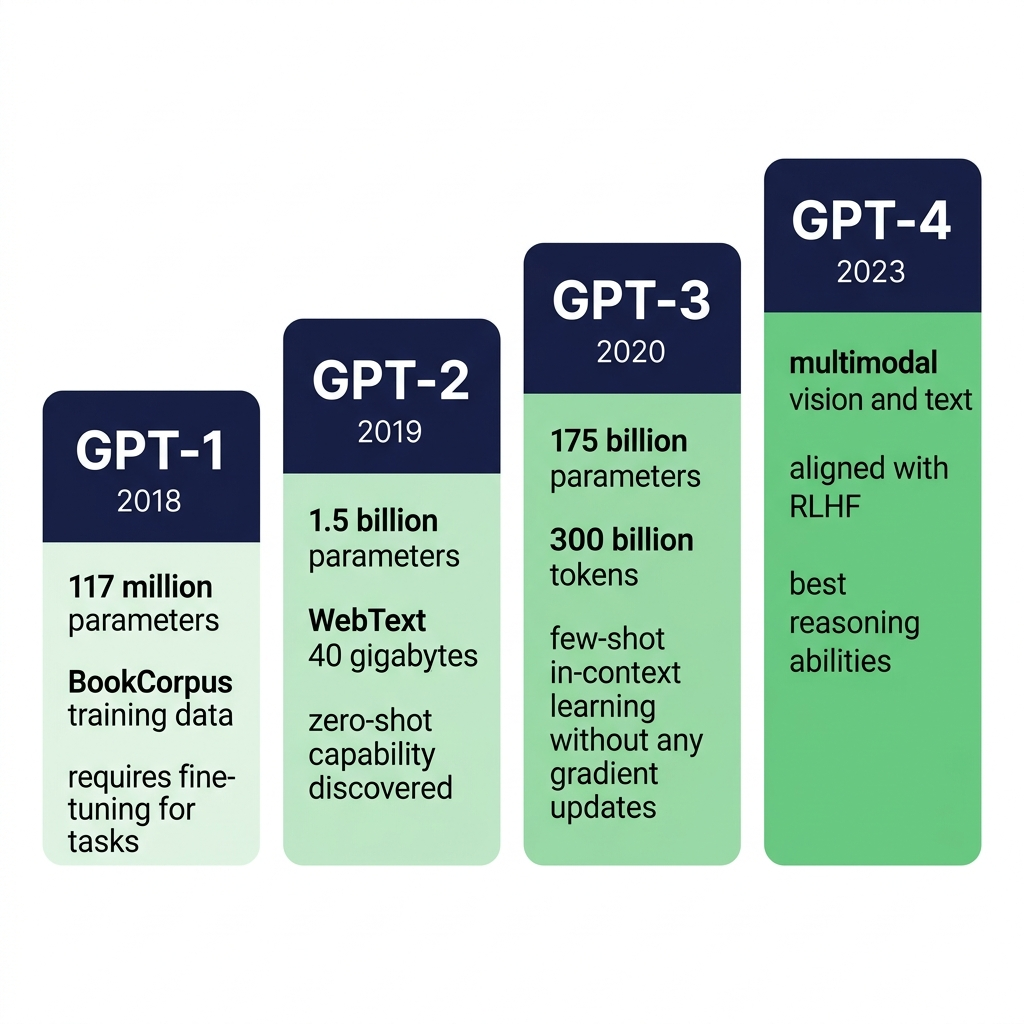

*Figure 1: GPT Evolution — Each generation dramatically scaled parameters and capabilities*

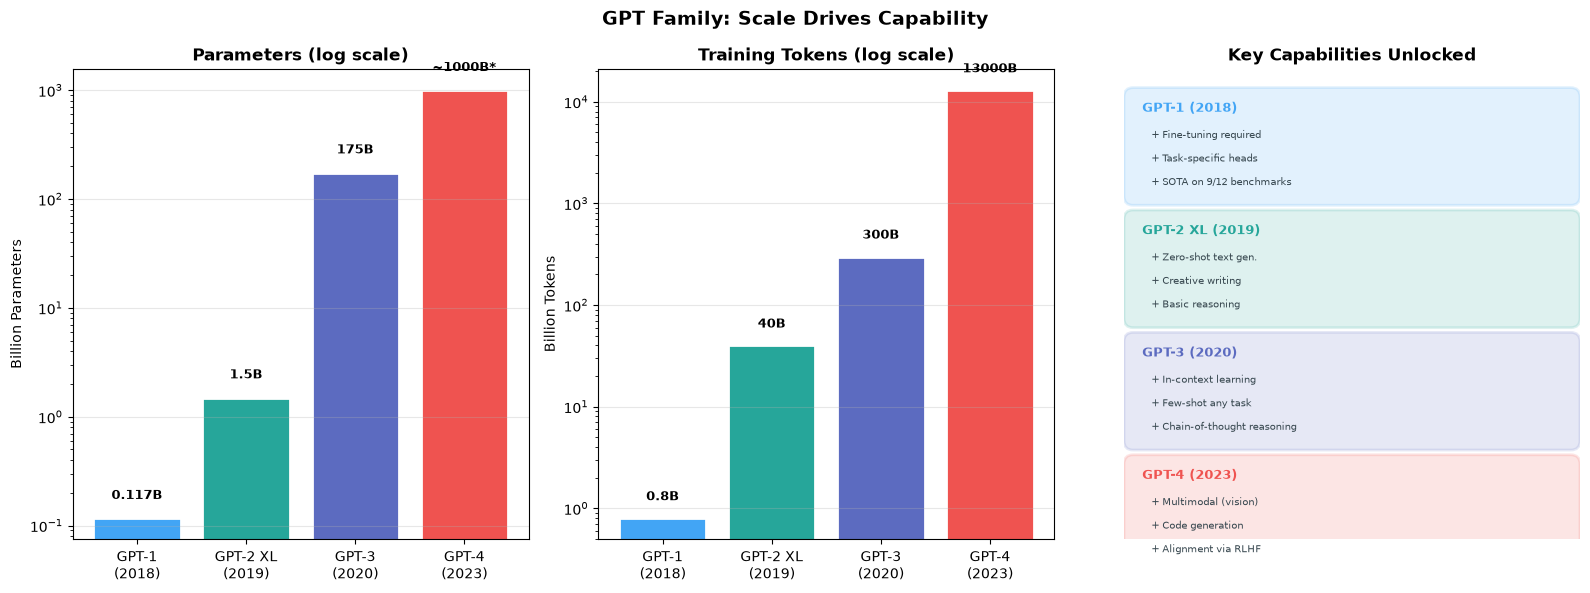

* GPT-4 parameter count is not officially disclosed. ~1T is a widely cited estimate.


In [1]:
# Visualize GPT model scaling progression
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models = ['GPT-1\n(2018)', 'GPT-2 XL\n(2019)', 'GPT-3\n(2020)', 'GPT-4\n(2023)']
params = [0.117, 1.5, 175, 1000]  # billions (GPT-4 estimated)
tokens = [0.8, 40, 300, 13000]     # billions of training tokens
capabilities = [
    ['Fine-tuning required', 'Task-specific heads', 'SOTA on 9/12 benchmarks'],
    ['Zero-shot text gen.', 'Creative writing', 'Basic reasoning'],
    ['In-context learning', 'Few-shot any task', 'Chain-of-thought reasoning'],
    ['Multimodal (vision)', 'Code generation', 'Alignment via RLHF', '128K context'],
]
colors = ['#42A5F5', '#26A69A', '#5C6BC0', '#EF5350']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Parameters
ax = axes[0]
bars = ax.bar(models, params, color=colors, edgecolor='white', lw=2)
ax.set_yscale('log')
ax.set_title('Parameters (log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Billion Parameters')
for bar, val in zip(bars, params):
    label = f'{val}B' if val < 1000 else f'~{val}B*'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.5,
            label, ha='center', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Training tokens
ax2 = axes[1]
bars2 = ax2.bar(models, tokens, color=colors, edgecolor='white', lw=2)
ax2.set_yscale('log')
ax2.set_title('Training Tokens (log scale)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Billion Tokens')
for bar, val in zip(bars2, tokens):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.5,
             f'{val}B', ha='center', fontsize=9, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Capabilities table
ax3 = axes[2]
ax3.axis('off')
ax3.set_title('Key Capabilities Unlocked', fontweight='bold', fontsize=12)
y_start = 0.95
for model, color, caps in zip(models, colors, capabilities):
    rect = mpatches.FancyBboxPatch((0.02, y_start - 0.22), 0.96, 0.21,
                                    boxstyle='round,pad=0.02',
                                    facecolor=color, alpha=0.15, edgecolor=color, lw=2)
    ax3.add_patch(rect)
    ax3.text(0.04, y_start - 0.02, model.replace('\n', ' '), fontsize=9,
             fontweight='bold', color=color, va='top')
    for j, cap in enumerate(caps[:3]):
        ax3.text(0.06, y_start - 0.08 - j*0.05, f'+ {cap}', fontsize=7.5,
                 color='#37474F', va='top')
    y_start -= 0.26

plt.suptitle('GPT Family: Scale Drives Capability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_gpt_scale_capabilities.png', dpi=150, bbox_inches='tight')
plt.show()
print('* GPT-4 parameter count is not officially disclosed. ~1T is a widely cited estimate.')

## 2. In-Context Learning: The Prompting Paradigm

The most surprising finding in the GPT-3 paper was that at sufficient scale, the model doesn't need weight updates to perform new tasks — it just needs **examples in the prompt**.

This is called **In-Context Learning (ICL)** and it comes in three forms:

### Zero-Shot
The prompt contains only a task description. No examples. The model must understand the intent from the instruction alone:
```
Classify the sentiment of this review:
Review: 'The product quality exceeded all my expectations.'
Sentiment:
```

### One-Shot
The prompt contains one example before the actual task:
```
Classify the sentiment of this review:
Review: 'Terrible product, broke after one day.' Sentiment: Negative

Review: 'The product quality exceeded all my expectations.'
Sentiment:
```

### Few-Shot
The prompt contains several demonstration examples:
```
Translate English to French:
sea → mer
cat → chat
house → maison
airplane →
```

The model learns the task format from the pattern of examples — **without any gradient updates**. This is fundamentally different from fine-tuning. The weights never change; the model uses its pre-trained knowledge plus the in-context examples.

---

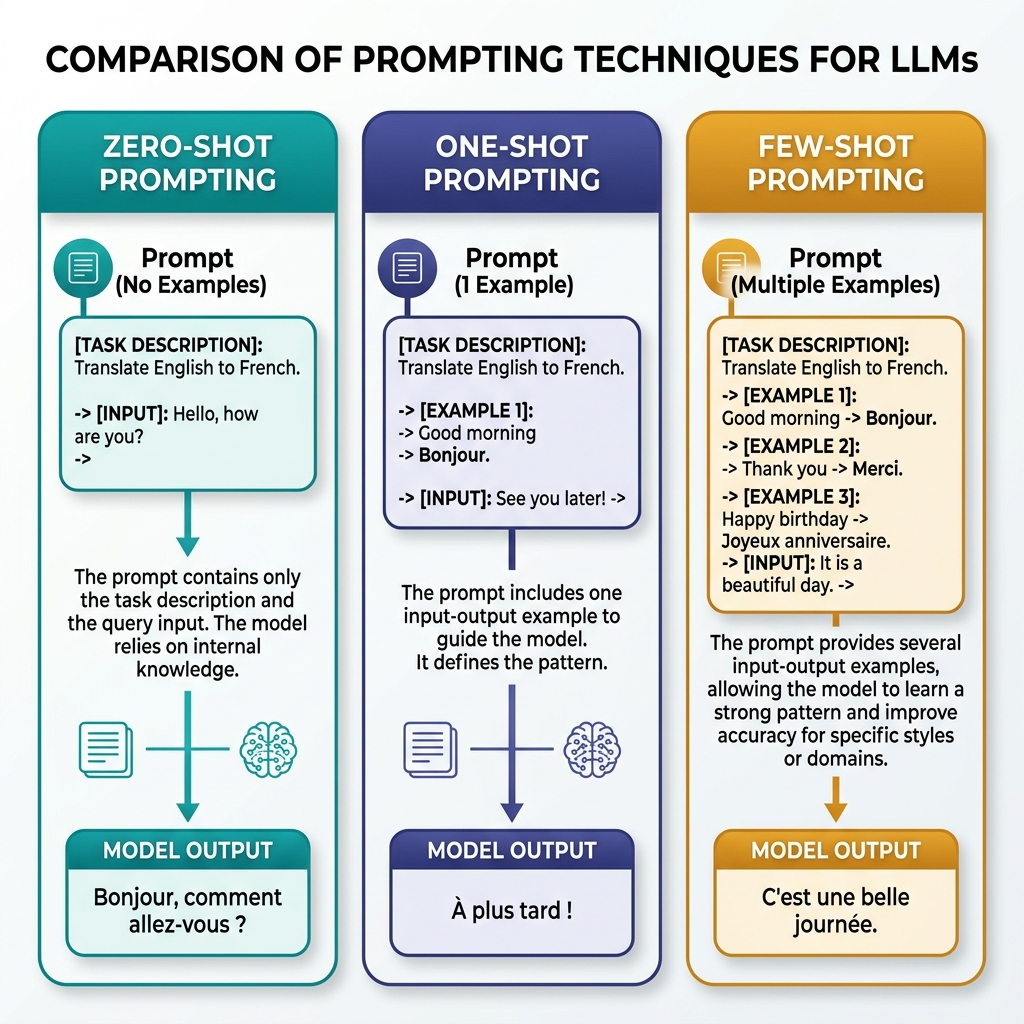

*Figure 2: In-Context Learning — Zero-shot, One-shot, and Few-shot prompting compared*



## 3. Emergent Abilities: What Scale Unlocks

Wei et al. (2022) documented a remarkable phenomenon: certain capabilities appear **abruptly** at specific model scales — they are absent at smaller sizes and then suddenly present at larger ones. This is called **emergence**:

| Ability | Approximate Emergence Scale |
|---|---|
| Basic arithmetic (3-digit addition) | ~7B parameters |
| Multi-step reasoning | ~100B parameters |
| Chain-of-thought (step-by-step reasoning) | ~100B parameters |
| Instruction following | ~100B parameters |
| Code synthesis from natural language | ~175B parameters |
| Complex logical reasoning | ~500B+ parameters |

### Chain-of-Thought Prompting
A striking emergent ability: if you ask GPT-3 to 'think step by step', it generates a reasoning chain that dramatically improves accuracy on math and logic problems:

```
WITHOUT CoT: Q: Roger has 5 tennis balls. He buys 2 more cans of 3 balls each.
              How many tennis balls does he have? A: 11  ← WRONG

WITH CoT:    Q: ... Let's think step by step. 
              A: Roger started with 5 balls. 2 cans × 3 balls = 6 balls.
                 5 + 6 = 11 tennis balls. The answer is 11. ← CORRECT
```

This emergent reasoning capability fundamentally changed how people think about LLMs — from 'autocomplete' to 'reasoning engines'.

---

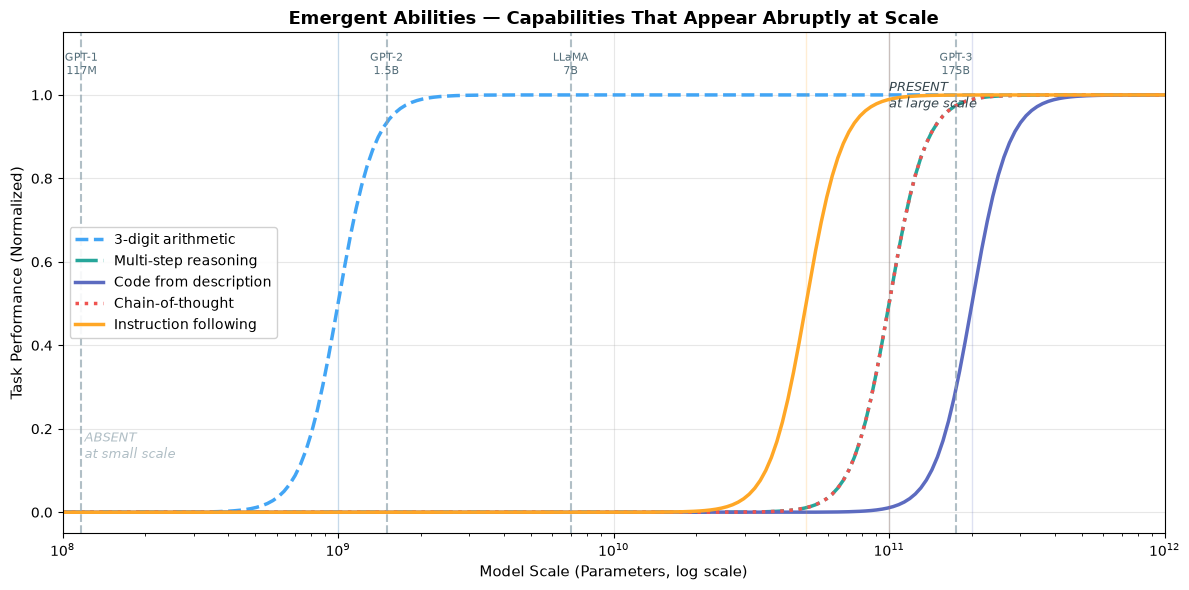

In [2]:
# Visualize emergent abilities across model scale
import matplotlib.pyplot as plt
import numpy as np

# Simulated emergence curves (step functions — appear abruptly)
scales = np.logspace(8, 12, 200)  # 100M to 1T parameters

def emergence_curve(scale, threshold, sharpness=15):
    """Sigmoid-like emergence at a specific threshold scale."""
    return 1 / (1 + np.exp(-sharpness * (np.log10(scale) - np.log10(threshold))))

abilities = [
    ('3-digit arithmetic',     1e9,   '#42A5F5', '--'),
    ('Multi-step reasoning',   1e11,  '#26A69A', '-.'),
    ('Code from description',  2e11,  '#5C6BC0', '-'),
    ('Chain-of-thought',       1e11,  '#EF5350', ':'),
    ('Instruction following',  5e10,  '#FFA726', '-'),
]

fig, ax = plt.subplots(figsize=(12, 6))
for name, threshold, color, ls in abilities:
    perf = emergence_curve(scales, threshold)
    ax.plot(scales, perf, color=color, lw=2.5, linestyle=ls, label=name)
    # Mark emergence threshold
    ax.axvline(threshold, color=color, alpha=0.2, lw=1)

# Reference model sizes
milestones = [(117e6, 'GPT-1\n117M'), (1.5e9, 'GPT-2\n1.5B'),
              (175e9, 'GPT-3\n175B'), (7e9, 'LLaMA\n7B')]
for size, label in milestones:
    ax.axvline(size, color='#90A4AE', lw=1.5, linestyle='dashed', alpha=0.7)
    ax.text(size, 1.05, label, ha='center', fontsize=8, color='#546E7A', rotation=0)

ax.set_xscale('log')
ax.set_xlim(1e8, 1e12)
ax.set_ylim(-0.05, 1.15)
ax.set_xlabel('Model Scale (Parameters, log scale)', fontsize=11)
ax.set_ylabel('Task Performance (Normalized)', fontsize=11)
ax.set_title('Emergent Abilities — Capabilities That Appear Abruptly at Scale',
             fontsize=13, fontweight='bold')
ax.legend(loc='center left', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.text(0.02, 0.15, 'ABSENT\nat small scale', transform=ax.transAxes,
        fontsize=9, color='#B0BEC5', style='italic')
ax.text(0.75, 0.85, 'PRESENT\nat large scale', transform=ax.transAxes,
        fontsize=9, color='#37474F', style='italic')
plt.tight_layout()
plt.savefig(r'outputs/p8_emergent_abilities.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. RLHF: From Language Model to Assistant (InstructGPT → ChatGPT)

The raw GPT-3 model is a powerful text predictor, but it has a critical misalignment: it was trained to *predict the next token of internet text*, not to *follow human instructions helpfully and safely*.

Ask raw GPT-3 "How do I bake a cake?" and it might complete the prompt as if it's a webpage — continuing with unrelated text, or generating a *question* back (since question-answer pairs appear together on the internet).

### The Three-Step RLHF Pipeline
OpenAI developed **Reinforcement Learning from Human Feedback (RLHF)** to align GPT-3:

**Step 1: Supervised Fine-Tuning (SFT)**
Human trainers write ideal responses to a diverse set of prompts. The model is fine-tuned on these demonstration pairs:
```
[Prompt]:   'Explain quantum entanglement to a 10-year-old.'
[Response]: 'Imagine two magic coins...'
```

**Step 2: Reward Model Training**
For the same prompts, the SFT model generates multiple responses. Human labelers rank them from best to worst. A **Reward Model (RM)** is trained to predict these human preference scores.

**Step 3: Reinforcement Learning (PPO)**
The SFT model is further trained using **Proximal Policy Optimization (PPO)** — a reinforcement learning algorithm. The language model generates responses, the Reward Model scores them, and PPO updates the weights to maximize reward while staying close to the SFT model (to avoid reward hacking).

---

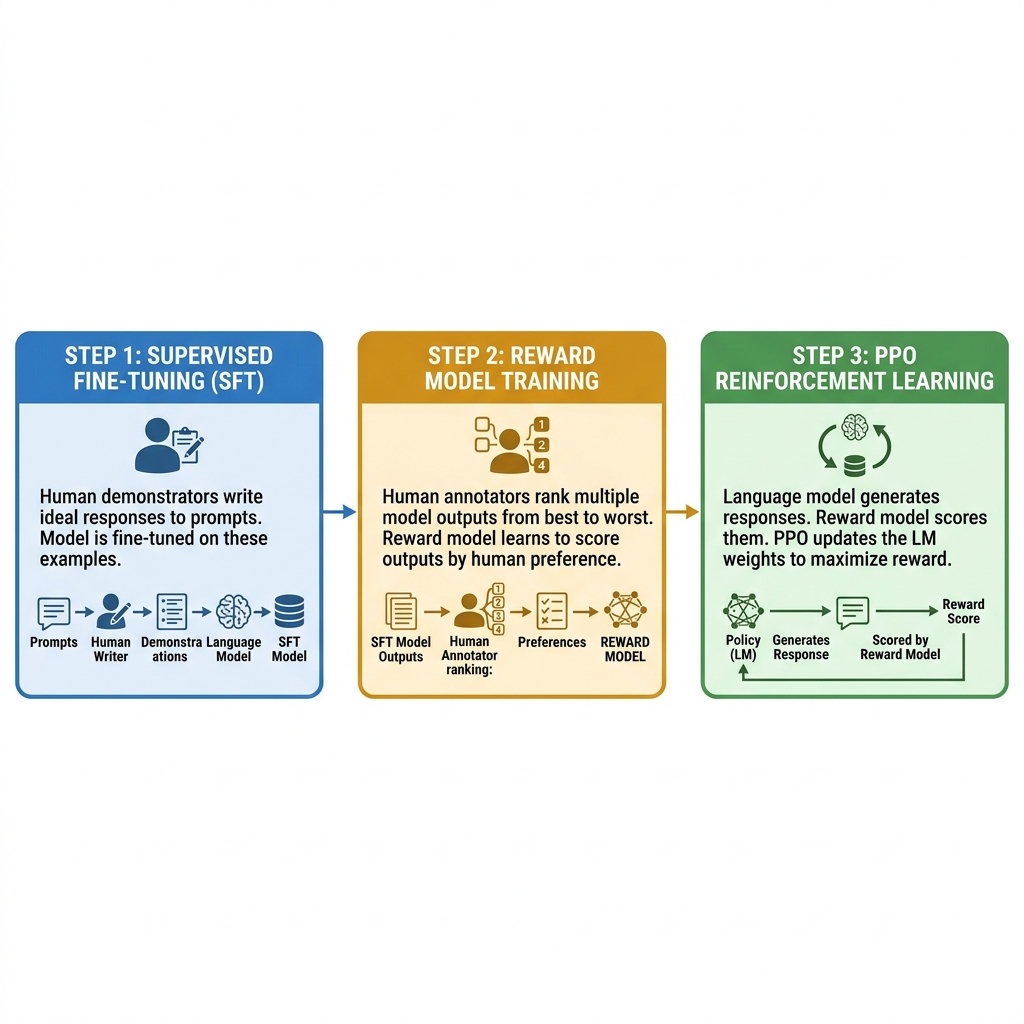

*Figure 3: RLHF Pipeline — Three steps from raw language model to aligned assistant*

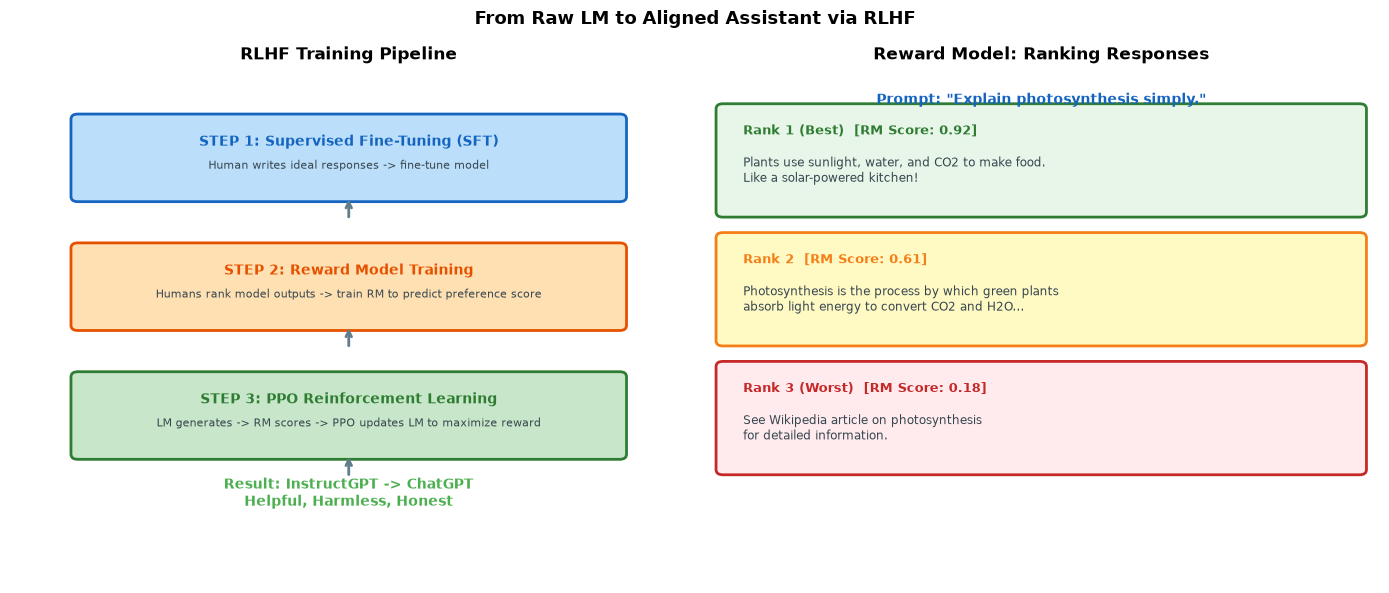

In [3]:
# Illustrate reward model scoring concept
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: RLHF 3-step pipeline diagram
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('RLHF Training Pipeline', fontweight='bold', fontsize=12)

steps = [
    (1.0, 7.5, 8.0, 1.5, '#1565C0', '#BBDEFB', 'STEP 1: Supervised Fine-Tuning (SFT)',
     'Human writes ideal responses -> fine-tune model'),
    (1.0, 5.0, 8.0, 1.5, '#E65100', '#FFE0B2', 'STEP 2: Reward Model Training',
     'Humans rank model outputs -> train RM to predict preference score'),
    (1.0, 2.5, 8.0, 1.5, '#2E7D32', '#C8E6C9', 'STEP 3: PPO Reinforcement Learning',
     'LM generates -> RM scores -> PPO updates LM to maximize reward'),
]
for x, y, w, h, ec, fc, title, desc in steps:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=fc, edgecolor=ec, lw=2)
    ax1.add_patch(rect)
    ax1.text(x+w/2, y+h-0.3, title, ha='center', va='top',
             fontsize=10, fontweight='bold', color=ec)
    ax1.text(x+w/2, y+h/2-0.15, desc, ha='center', va='center',
             fontsize=8, color='#37474F', wrap=True)
    if y > 2.4:
        ax1.annotate('', xy=(5, y), xytext=(5, y-0.5+0.05),
                    arrowprops=dict(arrowstyle='->', color='#607D8B', lw=2))
ax1.text(5, 1.5, 'Result: InstructGPT -> ChatGPT\nHelpful, Harmless, Honest',
         ha='center', fontsize=10, fontweight='bold', color='#4CAF50')

# Right: Reward model scoring examples
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Reward Model: Ranking Responses', fontweight='bold', fontsize=12)

prompt = 'Prompt: "Explain photosynthesis simply."'
ax2.text(5, 9.3, prompt, ha='center', fontsize=10, fontweight='bold',
         color='#1565C0')

responses = [
    ('Rank 1 (Best)',
     'Plants use sunlight, water, and CO2 to make food.\nLike a solar-powered kitchen!',
     0.92, '#2E7D32', '#E8F5E9'),
    ('Rank 2',
     'Photosynthesis is the process by which green plants\nabsorb light energy to convert CO2 and H2O...',
     0.61, '#F57F17', '#FFF9C4'),
    ('Rank 3 (Worst)',
     'See Wikipedia article on photosynthesis\nfor detailed information.',
     0.18, '#C62828', '#FFEBEE'),
]
for i, (rank, text, score, ec, fc) in enumerate(responses):
    y = 7.2 - i * 2.5
    rect = mpatches.FancyBboxPatch((0.3, y), 9.4, 2.0,
                                    boxstyle='round,pad=0.1',
                                    facecolor=fc, edgecolor=ec, lw=2)
    ax2.add_patch(rect)
    ax2.text(0.6, y+1.7, f'{rank}  [RM Score: {score:.2f}]',
             fontsize=9, fontweight='bold', color=ec, va='top')
    ax2.text(0.6, y+1.1, text, fontsize=8.5, color='#37474F', va='top')

plt.suptitle('From Raw LM to Aligned Assistant via RLHF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_rlhf_illustration.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. GPT-4 and the Modern LLM Era (2023)

GPT-4 represents the current frontier of the GPT family. While OpenAI has not disclosed exact architecture details, several key advances are known or well-evidenced:

### Multimodality
GPT-4 can process both **text and images** as input. You can describe a photograph, analyze a chart, or explain a diagram — capabilities that require connecting visual and linguistic representations.

### Extended Context
Context window expanded dramatically:
- GPT-3: 2,048 tokens
- GPT-3.5: 4,096 tokens
- GPT-4: 8,192 → 32,768 tokens
- GPT-4 Turbo: **128,000 tokens** (~96,000 words — an entire novel)

### Mixture of Experts (MoE) — Rumored Architecture
GPT-4 is widely believed to use a **Mixture of Experts** architecture: instead of one monolithic model, there are ~8 expert sub-models, and a routing mechanism selects 2 experts per input. This allows massive effective model capacity with lower inference cost per token.

### System Prompts and Persona
GPT-4 introduced **System Prompts** — a privileged instruction block that precedes the conversation and sets the model's behavior, persona, and constraints. This enabled products like ChatGPT (helpful assistant) and GitHub Copilot (code assistant) to be built on the same base model.

---

## 6. The Open-Source Response: LLaMA and Mistral

The GPT-3/4 success prompted the open-source community to replicate and improve:

| Model | Organization | Parameters | Key Innovation |
|---|---|---|---|
| **LLaMA** (2023) | Meta AI | 7B–65B | Open weights; competitive with GPT-3 |
| **LLaMA 2** (2023) | Meta AI | 7B–70B | Commercial license; instruction-tuned versions |
| **LLaMA 3** (2024) | Meta AI | 8B–70B | 128K context; strong reasoning |
| **Mistral 7B** (2023) | Mistral AI | 7B | Grouped Query Attention (GQA); sliding window attn |
| **Mixtral 8×7B** (2023) | Mistral AI | 46.7B active | Sparse MoE — 8 experts, 2 active per token |

### Grouped Query Attention (GQA) — An Important Efficiency Improvement
Standard multi-head attention: each attention head has its own Q, K, V.
GQA: multiple query heads share a single K,V pair → massive memory reduction at inference time, enabling longer contexts without proportional memory cost. This is now standard in most open-source LLMs.

---

## 7. Summary — The GPT Journey

| Milestone | Year | What Changed |
|---|---|---|
| GPT-1 | 2018 | Pre-training + fine-tuning paradigm established |
| GPT-2 | 2019 | Scale → zero-shot prompting discovered |
| GPT-3 | 2020 | 175B → in-context learning, few-shot generalization |
| InstructGPT | 2022 | RLHF aligns raw LM to follow human instructions |
| ChatGPT | 2022 | Consumer-facing product; 100M users in 2 months |
| GPT-4 | 2023 | Multimodal, 128K context, state-of-the-art reasoning |
| LLaMA/Mistral | 2023+ | Open-source models approach closed-model quality |

### What's Next
Notebook 8 places BERT and GPT side by side — comparing architectures, embedding spaces, and task suitability to give you a complete unified mental model.

---
*Phase 8, Notebook 7 of 10 — NLP From Scratch: Foundation to Advanced*